Part 7：Transfer Learning with EfficientNet-B0

In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
#Create model
from models.efficientnet import create_efficientnet

model = create_efficientnet()

print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Administrator/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 29.8MB/s]

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [3]:
#Device
from config import DEVICE

model = model.to(DEVICE)

In [4]:
#Optimizer
import torch.optim as optim

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)

In [5]:
#Loss
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

In [6]:
#Scheduler
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

In [8]:
from utils.train import train_one_epoch, evaluate

In [7]:
from utils.dataloader import get_dataloaders

train_loader, val_loader, test_loader = get_dataloaders()

In [19]:
#Training
import torch
train_losses = []
val_losses = []

train_accs = []
val_accs = []

results = []

best_acc = 0
num_epochs = 20

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    results.append({
        "Epoch": epoch + 1,
        "Train Loss": train_loss,
        "Validation Loss": val_loss,
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc
    })

    print(
        f"Epoch {epoch+1}/{num_epochs}"
        f" | Train Loss {train_loss:.4f}"
        f" | Train Acc {train_acc:.4f}"
        f" | Val Loss {val_loss:.4f}"
        f" | Val Acc {val_acc:.4f}"
    )

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "../weights/best_efficientnet.pth")
        print("✅ Best model saved.")

Epoch 1/20 | Train Loss 1.3239 | Train Acc 0.8069 | Val Loss 1.5492 | Val Acc 0.7608
✅ Best model saved.
Epoch 2/20 | Train Loss 1.3493 | Train Acc 0.7961 | Val Loss 1.5499 | Val Acc 0.7676
✅ Best model saved.
Epoch 3/20 | Train Loss 1.3391 | Train Acc 0.8108 | Val Loss 1.5425 | Val Acc 0.7490
Epoch 4/20 | Train Loss 1.3158 | Train Acc 0.7980 | Val Loss 1.5515 | Val Acc 0.7510
Epoch 5/20 | Train Loss 1.3540 | Train Acc 0.7971 | Val Loss 1.5150 | Val Acc 0.7706
✅ Best model saved.
Epoch 6/20 | Train Loss 1.3403 | Train Acc 0.7971 | Val Loss 1.5224 | Val Acc 0.7598
Epoch 7/20 | Train Loss 1.2927 | Train Acc 0.8186 | Val Loss 1.5214 | Val Acc 0.7598
Epoch 8/20 | Train Loss 1.3080 | Train Acc 0.8176 | Val Loss 1.5490 | Val Acc 0.7500
Epoch 9/20 | Train Loss 1.2971 | Train Acc 0.8118 | Val Loss 1.5408 | Val Acc 0.7480
Epoch 10/20 | Train Loss 1.2888 | Train Acc 0.8176 | Val Loss 1.5234 | Val Acc 0.7569
Epoch 11/20 | Train Loss 1.2744 | Train Acc 0.8118 | Val Loss 1.5156 | Val Acc 0.7686
Epo

In [20]:
#save results
from utils.save_results import save_training_results

df = save_training_results(
    results,
    "efficientnet_results.csv"
)

✅ Results saved to ..\results\efficientnet_results.csv


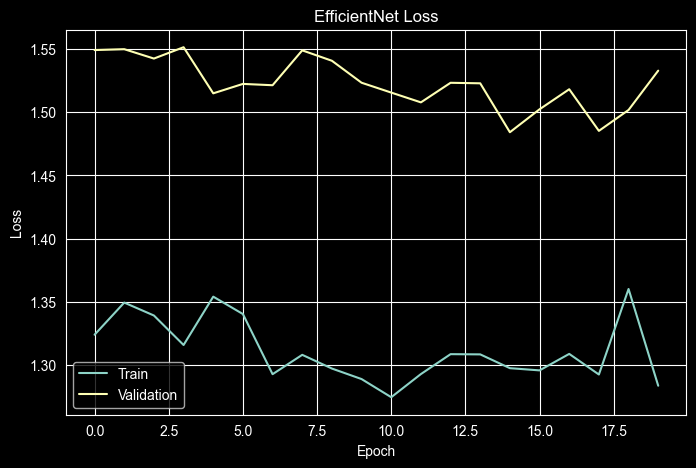

In [21]:
#Loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.title("EfficientNet Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

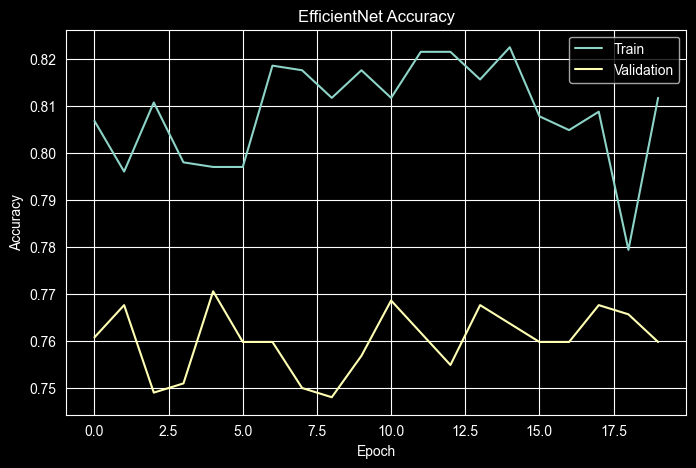

In [22]:
#Accuracy
plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Validation")
plt.title("EfficientNet Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()